In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the diabetes dataset
diabetes = pd.read_csv('D:/shap-reliability-research/data/diabetes.csv')

# First look at the data
print("Shape:", diabetes.shape)
print("\nFirst 5 rows:")
diabetes.head()


Shape: (768, 9)

First 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
# Check basic statistics
print("Basic Statistics:")
print(diabetes.describe())

print("\nMissing values per column:")
print(diabetes.isnull().sum())

print("\nOutcome distribution:")
print(diabetes['Outcome'].value_counts())

Basic Statistics:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.000000

In [4]:
# Check for zeros in columns where zero is medically impossible
cols_with_hidden_missing = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("Zero counts in medically impossible columns:")
for col in cols_with_hidden_missing:
    zero_count = (diabetes[col] == 0).sum()
    percentage = (zero_count / len(diabetes)) * 100
    print(f"{col}: {zero_count} zeros ({percentage:.1f}%)")

Zero counts in medically impossible columns:
Glucose: 5 zeros (0.7%)
BloodPressure: 35 zeros (4.6%)
SkinThickness: 227 zeros (29.6%)
Insulin: 374 zeros (48.7%)
BMI: 11 zeros (1.4%)


In [5]:
# Replace impossible zeros with median values
diabetes_clean = diabetes.copy()

for col in cols_with_hidden_missing:
    median_val = diabetes_clean[col].median()
    diabetes_clean[col] = diabetes_clean[col].replace(0, median_val)
    print(f"{col}: replaced zeros with median value of {median_val}")

print("\nVerify zeros are gone:")
for col in cols_with_hidden_missing:
    zero_count = (diabetes_clean[col] == 0).sum()
    print(f"{col}: {zero_count} zeros remaining")

Glucose: replaced zeros with median value of 117.0
BloodPressure: replaced zeros with median value of 72.0
SkinThickness: replaced zeros with median value of 23.0
Insulin: replaced zeros with median value of 30.5
BMI: replaced zeros with median value of 32.0

Verify zeros are gone:
Glucose: 0 zeros remaining
BloodPressure: 0 zeros remaining
SkinThickness: 0 zeros remaining
Insulin: 0 zeros remaining
BMI: 0 zeros remaining


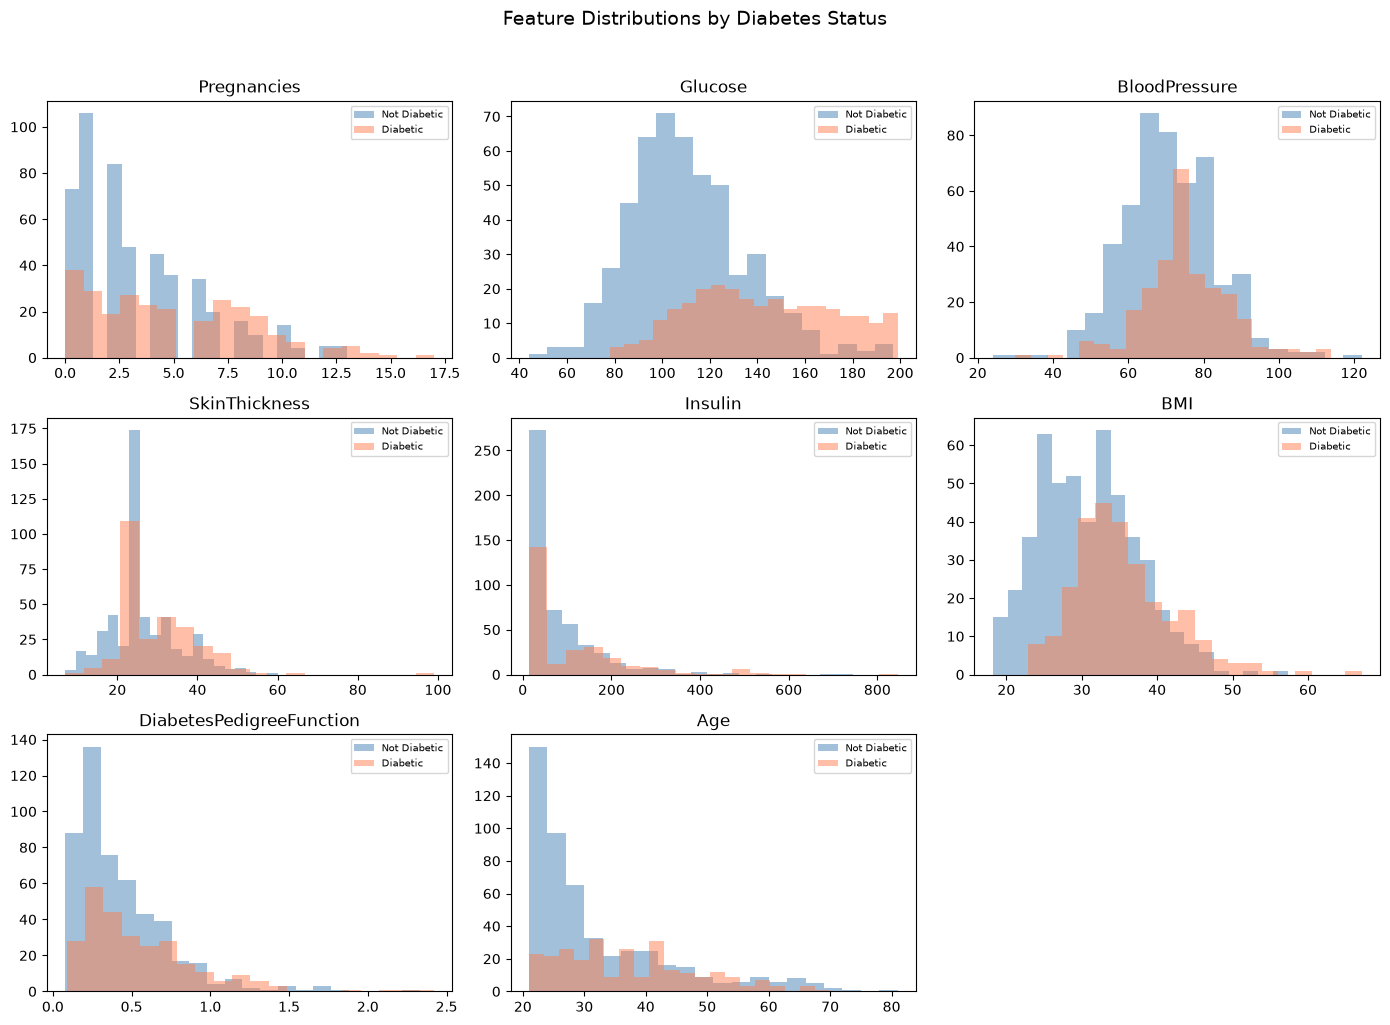

Plot saved to results/figures/


In [6]:
# Visualise feature distributions by outcome
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

features = ['Pregnancies', 'Glucose', 'BloodPressure', 
            'SkinThickness', 'Insulin', 'BMI', 
            'DiabetesPedigreeFunction', 'Age']

for i, col in enumerate(features):
    axes[i].hist(diabetes_clean[diabetes_clean['Outcome']==0][col], 
                 alpha=0.5, label='Not Diabetic', color='steelblue', bins=20)
    axes[i].hist(diabetes_clean[diabetes_clean['Outcome']==1][col], 
                 alpha=0.5, label='Diabetic', color='coral', bins=20)
    axes[i].set_title(col)
    axes[i].legend(fontsize=7)

axes[8].axis('off')
plt.suptitle('Feature Distributions by Diabetes Status', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('D:/shap-reliability-research/results/figures/feature_distributions.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to results/figures/")

In [7]:
# Save cleaned dataset
diabetes_clean.to_csv('D:/shap-reliability-research/data/diabetes_clean.csv', index=False)
print("Clean dataset saved successfully")
print("Shape:", diabetes_clean.shape)


Clean dataset saved successfully
Shape: (768, 9)


In [8]:
# Load and preview CKD dataset
ckd = pd.read_csv('D:/shap-reliability-research/data/kidney_disease.csv')
print("CKD Shape:", ckd.shape)
print("\nColumns:", ckd.columns.tolist())
print("\nFirst 5 rows:")
ckd.head()

CKD Shape: (400, 26)

Columns: ['id', 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'classification']

First 5 rows:


,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [9]:
# Check missing values in CKD dataset
print("Missing values per column:")
print(ckd.isnull().sum())

print("\nTarget distribution:")
print(ckd['classification'].value_counts())

Missing values per column:
id                  0
age                 9
bp                 12
sg                 47
al                 46
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                44
bu                 19
sc                 17
sod                87
pot                88
hemo               52
pcv                70
wc                105
rc                130
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64

Target distribution:
classification
ckd       248
notckd    150
ckd\t       2
Name: count, dtype: int64


In [10]:
# Fix the dirty target variable first
ckd['classification'] = ckd['classification'].str.strip()
print("Fixed target distribution:")
print(ckd['classification'].value_counts())

Fixed target distribution:
classification
ckd       250
notckd    150
Name: count, dtype: int64


In [11]:
# Separate the columns by data type
# because numerical and categorical columns
# need different strategies for filling missing values

# Numerical columns: fill missing values with the median
# (median is more robust than mean when data has outliers)
numerical_cols = ['age', 'bp', 'sg', 'al', 'su', 'bgr', 
                  'bu', 'sc', 'sod', 'pot', 'hemo', 
                  'pcv', 'wc', 'rc']

# Categorical columns: fill missing values with the mode
# (mode = most frequently occurring value)
categorical_cols = ['rbc', 'pc', 'pcc', 'ba', 'htn', 
                    'dm', 'cad', 'appet', 'pe', 'ane']

# Make a copy so we don't modify the original data
ckd_clean = ckd.copy()

# Fill numerical missing values with median
for col in numerical_cols:
    median_val = ckd_clean[col].median()  # calculate median of that column
    ckd_clean[col] = ckd_clean[col].fillna(median_val)  # replace NaN with median

# Fill categorical missing values with mode
for col in categorical_cols:
    mode_val = ckd_clean[col].mode()[0]  # [0] gets the first/most common value
    ckd_clean[col] = ckd_clean[col].fillna(mode_val)  # replace NaN with mode

# Verify all missing values are gone
print("Missing values remaining after cleaning:")
print(ckd_clean.isnull().sum().sum(), "total missing values")

TypeError: Cannot perform reduction 'median' with string dtype

In [13]:
# Check the data type of each column
# dtype tells us how pandas is reading each column
print("Column data types:")
print(ckd_clean.dtypes)

Column data types:
id                  int64
age               float64
bp                float64
sg                float64
al                float64
su                float64
rbc                   str
pc                    str
pcc                   str
ba                    str
bgr               float64
bu                float64
sc                float64
sod               float64
pot               float64
hemo              float64
pcv                   str
wc                    str
rc                    str
htn                   str
dm                    str
cad                   str
appet                 str
pe                    str
ane                   str
classification        str
dtype: object


In [14]:
# These columns should be numerical but are reading as strings
# We force-convert them to numbers using pd.to_numeric()
# errors='coerce' means: if a value can't be converted to a number,
# replace it with NaN (missing value) instead of crashing

cols_to_fix = ['pcv', 'wc', 'rc']

for col in cols_to_fix:
    ckd_clean[col] = pd.to_numeric(ckd_clean[col], errors='coerce')
    print(f"{col} converted — missing values now: {ckd_clean[col].isnull().sum()}")

# Verify they are now numeric
print("\nUpdated dtypes for fixed columns:")
print(ckd_clean[cols_to_fix].dtypes)

pcv converted — missing values now: 71
wc converted — missing values now: 106
rc converted — missing values now: 131

Updated dtypes for fixed columns:
pcv    float64
wc     float64
rc     float64
dtype: object


In [15]:
# Now correctly define numerical and categorical columns
# based on what we actually found in the data

numerical_cols = ['age', 'bp', 'sg', 'al', 'su', 'bgr', 
                  'bu', 'sc', 'sod', 'pot', 'hemo', 
                  'pcv', 'wc', 'rc']  # these are all now confirmed numeric

categorical_cols = ['rbc', 'pc', 'pcc', 'ba', 'htn', 
                    'dm', 'cad', 'appet', 'pe', 'ane']  # these are text categories

# Fill numerical missing values with median
for col in numerical_cols:
    median_val = ckd_clean[col].median()  # calculate median ignoring NaN
    ckd_clean[col] = ckd_clean[col].fillna(median_val)  # fill NaN with median
    
# Fill categorical missing values with mode (most frequent value)
for col in categorical_cols:
    mode_val = ckd_clean[col].mode()[0]  # get most common value
    ckd_clean[col] = ckd_clean[col].fillna(mode_val)  # fill NaN with mode

# Drop the id column — it's just a row number, not a medical feature
ckd_clean = ckd_clean.drop(columns=['id'])

# Verify everything is clean
print("Total missing values remaining:", ckd_clean.isnull().sum().sum())
print("Shape after cleaning:", ckd_clean.shape)

Total missing values remaining: 0
Shape after cleaning: (400, 25)


In [16]:
from sklearn.preprocessing import LabelEncoder

# LabelEncoder converts text categories into numbers
# e.g. "yes" -> 1, "no" -> 0
# e.g. "normal" -> 1, "abnormal" -> 0

le = LabelEncoder()  # create the encoder object

# List of all columns that contain text categories
cols_to_encode = ['rbc', 'pc', 'pcc', 'ba', 'htn', 
                  'dm', 'cad', 'appet', 'pe', 'ane', 
                  'classification']

for col in cols_to_encode:
    # Strip whitespace first to avoid encoding errors
    ckd_clean[col] = ckd_clean[col].str.strip()
    # Fit and transform: learn the categories then convert to numbers
    ckd_clean[col] = le.fit_transform(ckd_clean[col])
    print(f"{col}: encoded successfully")

# Preview the cleaned, encoded dataset
print("\nFirst 3 rows after encoding:")
ckd_clean.head(3)

rbc: encoded successfully
pc: encoded successfully
pcc: encoded successfully
ba: encoded successfully
htn: encoded successfully
dm: encoded successfully
cad: encoded successfully
appet: encoded successfully
pe: encoded successfully
ane: encoded successfully
classification: encoded successfully

First 3 rows after encoding:


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,48.0,80.0,1.02,1.0,0.0,1,1,0,0,121.0,...,44.0,7800.0,5.2,1,1,0,0,0,0,0
1,7.0,50.0,1.02,4.0,0.0,1,1,0,0,121.0,...,38.0,6000.0,4.8,0,0,0,0,0,0,0
2,62.0,80.0,1.01,2.0,3.0,1,1,0,0,423.0,...,31.0,7500.0,4.8,0,1,0,1,0,1,0


In [18]:
# Save the cleaned and encoded CKD dataset
# index=False means don't save the row numbers as a column
ckd_clean.to_csv('D:/shap-reliability-research/data/ckd_clean.csv', index=False)
print("Clean CKD dataset saved successfully")

Clean CKD dataset saved successfully


In [19]:
import os

# Check both clean files exist in the data folder
files = os.listdir('D:/shap-reliability-research/data/')
print("Files in data folder:")
for f in files:
    print(" -", f)

Files in data folder:
 - ckd_clean.csv
 - diabetes.csv
 - diabetes_clean.csv
 - kidney_disease.csv
